# The machine learning workflow with sklearn

The Hull textbook often does things "by hand" -- manually splitting data, standardizing variables with z-score formulas, and searching for hyperparameters by making graphs. In practice, `sklearn` can handle all of this for us.

This section covers the **practical workflow** for building prediction models: splitting your data, standardizing features, tuning hyperparameters with cross-validation, and combining everything into a **pipeline**.

We'll use the Zillow pricing error data from the previous section, along with the Hull housing data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

from sklearn.linear_model import Lasso, LassoCV, LassoLarsIC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error as mse

# Load the Zillow data
housing = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/properties_2016_sample10_1.csv')
pricing = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/train_2016_v2.csv')
zillow_data = pricing.merge(housing, on='parcelid', how='inner')
zillow_data['ln_calculatedfinishedsquarefeet'] = np.log(zillow_data['calculatedfinishedsquarefeet'])

# Load the Hull housing price data (already scaled)
data = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/Houseprice_data_scaled.csv')
train = data.iloc[:1800]
val = data.iloc[1800:2400]

## Prediction workflow with sklearn

`sklearn` has built-in tools that follow the machine learning workflow. If you use tools like Copilot or ChatGPT to write machine learning code, you're likely to get code that uses the `sklearn` workflow. So, we should understand how to use these tools.

This section starts off with the practical steps, assuming that you've already done your basic data cleaning.

### Splitting your data

Let's use `sklearn` and our Zillow data to **split the data into training and testing samples**. From Claude:

train_test_split is a function in the sklearn.model_selection module of the scikit-learn library in Python. It is used to split a dataset into two subsets: a training set and a test set. The training set is used to train a machine learning model, while the test set is used to evaluate its performance on unseen data.

The train_test_split function takes the following arguments:

- X: The feature matrix or data frame containing the input variables.
  
- y: The target vector or data frame containing the output variable(s).
  
- test_size (optional): The proportion of the dataset to include in the test split. It should be a float between 0.0 and 1.0. The default value is 0.25, which means 25% of the data will be used for testing.
  
- random_state (optional): An integer value used to seed the random number generator, which ensures reproducibility of the split.

The function returns four objects:

- X_train: The training data for the input features.
- X_test: The testing data for the input features.
- y_train: The training data for the target variable(s).
- y_test: The testing data for the target variable(s).

Notice that it doesn't do the train, validation, and test split from the Hull book. We can do training and validation within the training data set. I'll take my data frame *zillow_data* and split into target and features. Remember, *logerror* was the variable that we were trying to predict.

I added *z* to all of the names, just so I don't overwrite my data frames from above.

In [43]:
zillow_sample = zillow_data[['logerror', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'yearbuilt']]

yz = zillow_sample['logerror']
Xz = zillow_sample.drop('logerror', axis=1)

Xz_train, Xz_test, yz_train, yz_test = train_test_split(Xz, yz, test_size=0.2, random_state=42)

That will create four new data frames for you. I would make sure that you've cleaned and standardized everything before you split your data.

AI always chooses 42 to seed its random number generator. The answer to everything.

### Standardizing your data

Let's again use `sklearn` and our Zillow data to **standardize our data**. From Claude:

In scikit-learn (sklearn), you can standardize your data using the StandardScaler class from the sklearn.preprocessing module. Standardization is a common preprocessing step in machine learning that scales the features to have a mean of 0 and a standard deviation of 1. This can be beneficial for algorithms that are sensitive to feature scales.

- scaler = StandardScaler(): Create an instance of the StandardScaler class.
  
- X_scaled = scaler.fit_transform(X): Fit the scaler to the data and transform the data in one step. The fit_transform method first computes the mean and standard deviation of each feature based on the data in X, and then scales the features by subtracting the mean and dividing by the standard deviation.

The fit_transform method returns the scaled feature matrix X_scaled, where each feature now has a mean of 0 and a standard deviation of 1.

I am going to keep a few variables from the Zillow data, including our target *logerror*.

`scaler.fit_transform` creates an **array**. I convert this array back to a **data frame** and give the data frame the same column names as before. 


In [44]:
scaler = StandardScaler()
Xz_train_scaled = scaler.fit_transform(Xz_train)

Xz_train_scaled = pd.DataFrame(Xz_train_scaled, columns=Xz_train.columns)

Xz_train_scaled

,calculatedfinishedsquarefeet,lotsizesquarefeet,yearbuilt
0,-0.788359,-0.134278,-0.786796
1,-0.721827,-0.133585,-0.701616
2,1.191247,-0.134877,-0.403486
3,-0.152486,-0.120922,-0.914566
4,-0.875614,-0.073567,0.533494
...,...,...,...
7251,-0.224471,-0.018918,1.129754
7252,-0.391347,-0.134278,-0.488666
7253,-0.237560,-0.138870,-2.149677
7254,-1.267173,-0.157980,0.916804


Notice the steps above. I create the **scaler** object. It's defined using `StandardScaler()` which does the z-score method. I then use `.fit_transform()` with it. This method combines two tasks. First, it **fits the scaling method** by taking the mean and standard deviation for all of the features. Then, it **transforms my data** using the scaler. I save this in a new array, which I then turn back into a data frame.

We need to transform our y, or target variable as well. Again, we'll pay attention to data types. *yz_train* is a series, not a data frame. `scaler()` wants a data frame.

In [45]:
type(yz_train)

pandas.core.series.Series

In [46]:
yz_train= pd.DataFrame(yz_train)

In [47]:
yz_train

,logerror
2919,0.0247
4298,-0.1120
5082,0.1458
1643,-0.0182
7624,0.1178
...,...
5734,0.0478
5191,0.0611
5390,-0.0502
860,-0.0060


In [48]:
yz_train_scaled = scaler.fit_transform(yz_train)

yz_train_scaled = pd.DataFrame(yz_train_scaled, columns=yz_train.columns)

yz_train_scaled

,logerror
0,0.088347
1,-0.799853
2,0.875187
3,-0.190393
4,0.693259
...,...
7251,0.238438
7252,0.324854
7253,-0.398311
7254,-0.111124


Now, what about the **testing data**? From Claude:

When scaling your test data using scikit-learn's scalers (e.g., StandardScaler, MinMaxScaler, etc.), **you should use the mean and standard deviation (or the minimum and maximum values for MinMaxScaler) computed from the training data**. This is to ensure that the test data is scaled using the same parameters as the training data, which is crucial for preventing data leakage and maintaining consistency between the training and testing data distributions.

Watch my steps here, as they are different from above. I again create my **scaler object**, calling it *scaler*. You could create multiple scalers with different names if you wanted to.

I then **fit this scaler using my unscaled training data**. This is what I did above, except there I used `.fit_transform`, which fits the scaler and then transforms the data, all in one step. Now, I'm **fitting my scaler with one data set and then transforming a different data set**.

I then take this fitted scaler that has the means and standard deviations from my **training data**. I use those to **transform my testing data**. 

In [49]:
scaler = StandardScaler()
scaler.fit(Xz_train)
Xz_test_scaled = scaler.transform(Xz_test)


I follow the same logic for my y target test data.

In [50]:
yz_test= pd.DataFrame(yz_test)
yz_test

,logerror
447,0.0227
3018,0.4337
8579,0.3941
5509,-0.0182
5279,0.0030
...,...
6658,0.2191
6734,0.0188
7904,-0.0429
1244,-0.0736


In [51]:
yz_train

,logerror
2919,0.0247
4298,-0.1120
5082,0.1458
1643,-0.0182
7624,0.1178
...,...
5734,0.0478
5191,0.0611
5390,-0.0502
860,-0.0060


In [52]:
scaler = StandardScaler()
scaler.fit(yz_train)
yz_test_scaled = scaler.transform(yz_test)

### Cross-validation and hyperparameters

Let's discuss an idea called [cross validation](https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_model_selection.html). We've already seen this a bit when we split our data into **training** and **validation** samples. From Claude:

> Cross-validation is a technique used in machine learning to evaluate the performance of a model and tune its hyperparameters. It helps to estimate how well the model will generalize to unseen data, and it is particularly useful when the available data is limited. The main idea behind cross-validation is to split the dataset into two parts: a training set and a validation set. The model is trained on the training set and evaluated on the validation set. This process is repeated multiple times, with different portions of the data being used for training and validation in each iteration.

> There are several types of cross-validation techniques, but the most common is **k-fold cross-validation**. Here's how it works:

1. The dataset is randomly partitioned into k equal-sized subsets or "folds".

2. One of the k folds is held out as the validation set, and the remaining k-1 folds are used for training the model. The model is trained on the k-1 folds and evaluated on the held-out validation fold.

3. This process is repeated k times, with each of the k folds being used as the validation set exactly once.

4. The performance metric (e.g., accuracy, F1-score, mean squared error) is calculated for each iteration, and the final performance is the average of the k iterations.

5. Cross-validation has several advantages:

- It provides a more reliable and unbiased estimate of the model's performance compared to a single train-test split.

- It helps to prevent overfitting by evaluating the model on data that it has not seen during training.

- It allows for effective hyperparameter tuning by selecting the hyperparameters that yield the best average performance across the cross-validation folds.

- It makes efficient use of the available data by using every data point for both training and validation at some point.

- Cross-validation is widely used in machine learning competitions, research, and real-world applications. It is a crucial technique for evaluating and tuning models, especially when dealing with limited data or when it is important to estimate the model's generalization performance accurately.

We are going to use some **built-in cross-validation tools**. This means that we don't have to manually split our data set. 

I'm going to go back to the Hull data and **combine the training and validation data sets**. I'm going to use all of the observations and have `sklearn` perform the cross-fold validation for me. 

Let me create my new data frames. This is the Hull data, so it's already cleaned up and standardized.

In [53]:
combined_train = pd.concat([train, val], ignore_index=True)

X_combined_train = combined_train.drop('Sale Price', axis=1)
y_combined_train= combined_train[['Sale Price']]

I will now search for the optimal hyperparameter (i.e. alpha) value for a LASSO model using **cross-validation**. I am going to take each alpha (e.g. 0.001) and try it five times in my training data. Each time, I will "hold out" 20% of my training data, estimate a model on 80% of the data using that alpha value. I'll save my R-Square value from that model as a measure of fit. I'll then do that four more times for that alpha parameter, holding out a different 20% of my training data each time. That will give me five different R-Square values for each alpha. I'll then take an average of those R-Square values as my estimate for how well that alpha value performs. Remember, a larger R-Square means that the model "fits" the data better - the model is better able to use your features to explain your targets.

This process is repeated for each alpha value.

We are going to use `GridSearchCV` to do this. From Claude:

GridSearchCV is a class in scikit-learn that helps you perform an exhaustive search over specified parameter values for an estimator (a machine learning model or algorithm). It is used to find the optimal combination of hyperparameters that maximizes the performance of a machine learning model on a given dataset.



And a visual explanation of the process.

```{figure} ../images/12-cross-validation.png
---
name: 12-cross-validation.png
align: center
---
Holding out different parts of our training data in order to search for optimal hyperparameters. Source:Justintodata.com
```

In [54]:
# Tune the LASSO hyperparameter (alpha) using the validation set
param_grid = {'alpha': [0.001, 0.01, 0.02, .05, 0.1]}
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
grid_search.fit(X_combined_train, y_combined_train)

# Extract the R-squared scores for each fold and hyperparameter combination
r2_scores = grid_search.cv_results_['mean_test_score']

# Print the R-squared scores
print(r2_scores)

[0.87838353 0.87833852 0.87472463 0.8567964  0.83113931]


As we already knew, lower alphas give us better results in our training data. We can use this method to **select a single set of hyperparameters** to then use on our **testing data**.

## Pipelines

`sklearn` lets us combine many of these steps together. I'm going to [follow along with this example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_model_selection.html) and try something a little fancier. We will use some different model fit statistics to perform cross-validation within our training sample and have the pipeline **choose our hyperparameters for us**. 

`pipelines` can do much, much more than I show here. Take a look: <https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html>

Since I want to use some data that hasn't been standardized yet, I'll go back to the Zillow example. I'll keep some more numerical variables that will be easy to standardize.

I will not include any indicators or other data transformations. If I was doing this for real, I would spend a lot more time doing some feature engineering.

A few things to note:

- I'm using `make_pipeline`. This is a very common and useful function that lets you take your features, scale them, define criteria for model selection, etc. You basically transform your data in a series of steps and then ask for the model. 
  
- I'm asking for the [aic criterion](https://en.wikipedia.org/wiki/Akaike_information_criterion). This is a measure of best fit. I will also ask for the [bic criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion), another measure of best fit. The smaller the value, the better the model fits the data.
  
- `LassoLarsIC` tells the code to run the lasso model, which we then fit on our training data. This function is going to pick a bunch of alpha values for us, fit the model, and report the requested criterion back to us.


Here's a description of `make_pipeline` from Claude:

- `make_pipeline` is a utility function provided by scikit-learn that creates a Pipeline object, which is a sequence of transformers and an estimator. It is a convenient way to chain multiple estimators into a single unit. The make_pipeline function takes any number of estimators as arguments and returns a Pipeline object. The estimators are applied in the order they are passed to the function. The last estimator is always a classifier or regressor, while the other estimators are transformers (preprocessors).

- Some key features and benefits of using make_pipeline are:

- **Convenience**: It provides a simple and readable way to define a sequence of estimators, making the code more concise and easier to maintain.

- **Automated Data Flow**: The Pipeline object automatically applies the transformers to the input data and passes the transformed data to the final estimator. This avoids the need to manually handle the data flow between estimators.

- **Consistency**: All estimators in the pipeline, except the last one, must be transformers (i.e., have a transform method). This consistency makes it easier to understand and reason about the data flow.

- **Persistence**: The entire pipeline can be persisted to disk using the joblib module, making it easy to reuse the same preprocessing and modeling steps in different environments.

- **Parallelization**: Some transformers in the pipeline can be parallelized using the n_jobs parameter, potentially leading to faster processing times.

- **Cross-Validation**: The entire pipeline can be used in cross-validation loops, ensuring that the same preprocessing steps are applied to both the training and validation data.

- Overall, make_pipeline simplifies the process of chaining multiple estimators together and helps to create more readable, maintainable, and efficient code for machine learning workflows.

Here's my `make_pipeline`. I am fitting a LASSO model, where I have it use the AIC criteria to pick the "best" hyperparameter. It then fit the model using our new combined training data.

There's a little bit of data manipulation that `make_pipeline` wants me to do. From Claude:

y_train.values converts the pandas DataFrame y_train to a NumPy array.
.ravel() is then applied to the NumPy array, which flattens the array into a 1-dimensional array (required by the LassoLarsIC estimator).

I need to do a little data cleaning on this Zillow data to get it to work in our pipeline.


In [55]:
zillow_sample = zillow_data[['logerror','bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'fireplacecnt', 
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft','lotsizesquarefeet', 
       'poolcnt', 'poolsizesum', 'yearbuilt', 'numberofstories']]


In [56]:
zillow_sample

,logerror,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,lotsizesquarefeet,poolcnt,poolsizesum,yearbuilt,numberofstories
0,0.0962,3.0,2.0,1798.0,NaN,3.0,NaN,NaN,7302.0,NaN,NaN,1936.0,NaN
1,0.0020,3.0,4.0,2302.0,1.0,3.0,2.0,671.0,7258.0,1.0,500.0,1980.0,2.0
2,-0.0566,2.0,3.0,1236.0,NaN,2.0,NaN,NaN,5076.0,NaN,NaN,1957.0,NaN
3,0.0227,2.0,2.0,1413.0,NaN,2.0,NaN,NaN,7725.0,NaN,NaN,1953.0,NaN
4,0.0237,3.5,3.0,2878.0,1.0,3.0,2.0,426.0,10963.0,NaN,NaN,2003.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9066,-0.0305,3.0,5.0,2465.0,NaN,3.0,NaN,NaN,4999.0,NaN,NaN,1931.0,NaN
9067,0.0266,3.0,3.0,1726.0,NaN,3.0,NaN,NaN,187293.0,1.0,NaN,1981.0,NaN
9068,0.0090,2.0,4.0,1393.0,NaN,2.0,2.0,451.0,6279.0,NaN,NaN,1963.0,1.0
9069,0.0497,2.0,3.0,1967.0,NaN,2.0,NaN,NaN,18129.0,NaN,NaN,1951.0,NaN


For some of these counts, missings are actually zeroes. I can glance at the data and see, however, that this isn't true for all observations. For example we have a poolcnt = 1, but poolsizesum = 0. I'll go ahead and just fill in the missings for the purpose of this exercise. But, not great!

In [57]:
# Set missing observations to zero
zillow_sample = zillow_sample.fillna(0)

zillow_sample

,logerror,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,lotsizesquarefeet,poolcnt,poolsizesum,yearbuilt,numberofstories
0,0.0962,3.0,2.0,1798.0,0.0,3.0,0.0,0.0,7302.0,0.0,0.0,1936.0,0.0
1,0.0020,3.0,4.0,2302.0,1.0,3.0,2.0,671.0,7258.0,1.0,500.0,1980.0,2.0
2,-0.0566,2.0,3.0,1236.0,0.0,2.0,0.0,0.0,5076.0,0.0,0.0,1957.0,0.0
3,0.0227,2.0,2.0,1413.0,0.0,2.0,0.0,0.0,7725.0,0.0,0.0,1953.0,0.0
4,0.0237,3.5,3.0,2878.0,1.0,3.0,2.0,426.0,10963.0,0.0,0.0,2003.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9066,-0.0305,3.0,5.0,2465.0,0.0,3.0,0.0,0.0,4999.0,0.0,0.0,1931.0,0.0
9067,0.0266,3.0,3.0,1726.0,0.0,3.0,0.0,0.0,187293.0,1.0,0.0,1981.0,0.0
9068,0.0090,2.0,4.0,1393.0,0.0,2.0,2.0,451.0,6279.0,0.0,0.0,1963.0,1.0
9069,0.0497,2.0,3.0,1967.0,0.0,2.0,0.0,0.0,18129.0,0.0,0.0,1951.0,0.0


In [58]:
yz = zillow_sample.loc[:, 'logerror'] 
Xz = zillow_sample.drop('logerror', axis=1)

Xz_train, Xz_test, yz_train, yz_test = train_test_split(Xz, yz, test_size=0.2, random_state=42)

In [59]:
Xz_train

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,lotsizesquarefeet,poolcnt,poolsizesum,yearbuilt,numberofstories
2919,1.0,2.0,1041.0,0.0,1.0,1.0,360.0,6120.0,0.0,0.0,1950.0,1.0
4298,1.0,3.0,1102.0,0.0,1.0,0.0,0.0,6259.0,1.0,0.0,1952.0,0.0
5082,3.5,6.0,2856.0,0.0,3.0,1.0,360.0,6000.0,0.0,0.0,1959.0,1.0
1643,3.0,4.0,1624.0,0.0,3.0,0.0,0.0,8799.0,0.0,0.0,1947.0,0.0
7624,2.0,2.0,961.0,0.0,2.0,0.0,0.0,18297.0,0.0,0.0,1981.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5734,3.0,2.0,1558.0,0.0,3.0,0.0,0.0,29258.0,1.0,0.0,1995.0,0.0
5191,2.0,4.0,1405.0,0.0,2.0,2.0,441.0,6120.0,0.0,0.0,1957.0,1.0
5390,2.0,3.0,1546.0,0.0,2.0,0.0,0.0,5199.0,0.0,0.0,1918.0,0.0
860,1.0,1.0,602.0,0.0,1.0,1.0,0.0,1366.0,0.0,0.0,1990.0,0.0


In [60]:
Xz_test

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,lotsizesquarefeet,poolcnt,poolsizesum,yearbuilt,numberofstories
447,2.0,2.0,1671.0,1.0,2.0,1.0,389.0,1750.0,0.0,0.0,1981.0,3.0
3018,1.0,3.0,859.0,0.0,1.0,0.0,0.0,3456.0,0.0,0.0,1940.0,0.0
8579,2.0,4.0,1840.0,0.0,2.0,0.0,0.0,7173.0,0.0,0.0,1965.0,0.0
5509,2.0,4.0,1200.0,0.0,2.0,0.0,0.0,7740.0,0.0,0.0,1955.0,0.0
5279,2.5,3.0,1604.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1989.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6658,2.0,2.0,947.0,0.0,2.0,0.0,0.0,72341.0,0.0,0.0,1974.0,0.0
6734,2.0,3.0,1974.0,0.0,2.0,0.0,0.0,6304.0,0.0,0.0,1964.0,0.0
7904,3.0,2.0,1888.0,0.0,3.0,0.0,0.0,122753.0,1.0,0.0,1972.0,0.0
1244,1.0,1.0,600.0,0.0,1.0,0.0,0.0,46486.0,1.0,0.0,2004.0,0.0


In [61]:
yz_train

2919    0.0247
4298   -0.1120
5082    0.1458
1643   -0.0182
7624    0.1178
         ...  
5734    0.0478
5191    0.0611
5390   -0.0502
860    -0.0060
7270    0.0286
Name: logerror, Length: 7256, dtype: float64

In [62]:
yz_test

447     0.0227
3018    0.4337
8579    0.3941
5509   -0.0182
5279    0.0030
         ...  
6658    0.2191
6734    0.0188
7904   -0.0429
1244   -0.0736
8622   -0.0502
Name: logerror, Length: 1815, dtype: float64

Time to make the `pipeline`. This is going to use the standard scaler on my training data and run a Lasso model, here the hyperparameter is selected using the AIC criteria.

Again, note how the X features sets are data frames, while the y target set are series.

In [63]:
lasso_lars_ic = make_pipeline(StandardScaler(), LassoLarsIC(criterion="aic")).fit(Xz_train, yz_train.values.ravel())

In [64]:
results = pd.DataFrame(
    {
        "alphas": lasso_lars_ic[-1].alphas_,
        "AIC criterion": lasso_lars_ic[-1].criterion_,
    }
).set_index("alphas")
alpha_aic = lasso_lars_ic[-1].alpha_

Same thing as above, but now using the BIC selection criteria.

In [65]:
lasso_lars_ic.set_params(lassolarsic__criterion="bic").fit(Xz_train, yz_train.values.ravel())
results["BIC criterion"] = lasso_lars_ic[-1].criterion_
alpha_bic = lasso_lars_ic[-1].alpha_

You can see below that small values of alpha give us the best model fit, no matter the criteria used. This confirms what we saw graphically above. 

In [66]:
def highlight_min(x):
    x_min = x.min()
    return ["font-weight: bold" if v == x_min else "" for v in x]

results.style.apply(highlight_min)

,AIC criterion,BIC criterion
alphas,,
0.008193,-6566.197538,-6566.197538
0.006502,-6571.833764,-6564.944180
0.006250,-6570.829907,-6557.050739
0.006217,-6568.983921,-6548.315169
0.005552,-6572.082467,-6551.413715
0.004159,-6577.437720,-6556.768968
0.004015,-6576.114858,-6548.556522
0.002618,-6581.223880,-6546.775960
0.002365,-6580.648359,-6539.310855


This table highlights the optimal alpha hyperparameter based on two different selection criteria.

Let's make a plot. We'll use `matplotlib` and the *ax* method.

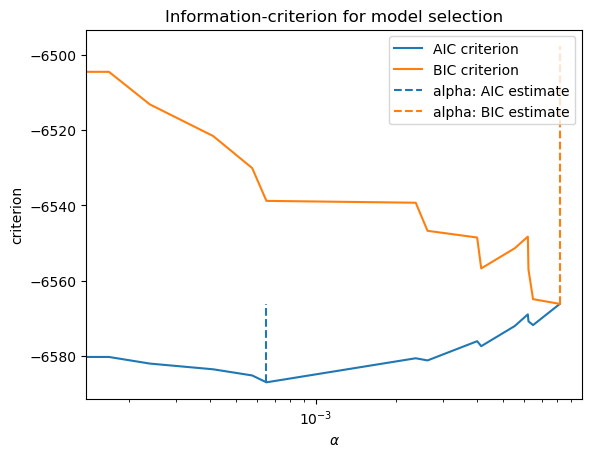

In [67]:
ax = results.plot()
ax.vlines(
    alpha_aic,
    results["AIC criterion"].min(),
    results["AIC criterion"].max(),
    label="alpha: AIC estimate",
    linestyles="--",
    color="tab:blue",
)
ax.vlines(
    alpha_bic,
    results["BIC criterion"].min(),
    results["BIC criterion"].max(),
    label="alpha: BIC estimate",
    linestyle="--",
    color="tab:orange",
)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("criterion")
ax.set_xscale("log")
ax.legend()
_ = ax.set_title(
    f"Information-criterion for model selection"
)

This doesn't look as continuous as it will in practice. The lines are jumping around quite a bit. The reason: We actually don't have that many features in this Zillow data set that I'm using. Our machine learning tools will work, but are probably unnecessary. Just run a regression!

Let's create a new pipeline using **cross-validation**, rather than using the AIC or BIC criteria. What's the difference? From Claude:

**LassoCV** uses cross-validation to find the optimal alpha value that minimizes a chosen scoring metric, making it more robust but computationally expensive.
**LassoLarsIC(criterion="aic")** uses the Akaike Information Criterion (AIC) to find the optimal alpha value, providing a faster but potentially less accurate estimate than cross-validation.

In [68]:
modelcv = make_pipeline(LassoCV(cv=20)).fit(Xz_train, yz_train)

Again, *modelcv* is a pipeline. A pipeline is an object. This object contains our lasso model fit. We'll pull this out below and define it as *lasso*. 

In [69]:
modelcv

Pipeline(steps=[('lassocv', LassoCV(cv=20))])

In [70]:
lasso = modelcv[-1]
lasso

LassoCV(cv=20)

OK, what did we do here? Let's have Claude tell us:

In scikit-learn, LassoCV(cv=20) refers to the Lasso regression model with cross-validation for tuning the regularization parameter (alpha). Here's what the components mean:

- LassoCV: This is the class name for the Lasso regression model with built-in cross-validation for automatically tuning the regularization strength parameter (alpha).

- cv=20: This is a parameter that specifies the number of folds for cross-validation. In this case, it means that the cross-validation process will be repeated 20 times, each time using a different 1/20th of the data as the validation set and the remaining 19/20ths as the training set.

- The LassoCV class performs the following steps:

1. It splits the data into cv (20 in this case) folds or subsets.

2. For each fold:

2a. It holds out that fold as the validation set.

2b. It trains the Lasso regression model on the remaining cv-1 folds, using a range of different alpha values.

2c. It evaluates the performance of the model on the held-out validation fold for each alpha value.

- After all folds have been processed, it selects the alpha value that gives the best average performance across all folds.

- Finally, it retrains the Lasso regression model on the entire dataset using the optimal alpha value found through cross-validation.

By using cross-validation, LassoCV can automatically find the optimal value of the regularization parameter (alpha) that balances the trade-off between model complexity and goodness of fit. This helps to prevent overfitting and improve the model's generalization performance. The choice of cv = 20 is a common practice, as it provides a good balance between computational cost and reliable estimation of the model's performance. However, the optimal value of cv can depend on the size of the dataset and the complexity of the problem.

I can print out the parameters contained in my LASSO model. This will tell you the details of how things were estimated.

In [71]:
lasso.get_params()


{'alphas': None,
 'copy_X': True,
 'cv': 20,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 100,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

I can also pull out the hyperparameter that was eventually chosen using cross-validation.

In [72]:
lasso.alpha_

0.9233932158250625

That's a large hyperparameter. Lots of features were dropped. Let's look.

I'll make a table that has the coefficients from the final model estimated using my training data. Square feet of house and lot are all that are selected. The LASSO model drops every other feature.

In [73]:
feature_names = list(Xz_train.columns) 
coefficients = lasso.coef_

# Create a DataFrame with feature names and coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of coefficients in descending order
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

coef_df

,Feature,Coefficient
2,calculatedfinishedsquarefeet,7.260294e-06
7,lotsizesquarefeet,1.356992e-08
0,bathroomcnt,0.000000e+00
1,bedroomcnt,0.000000e+00
3,fireplacecnt,0.000000e+00
4,fullbathcnt,0.000000e+00
5,garagecarcnt,0.000000e+00
6,garagetotalsqft,0.000000e+00
8,poolcnt,0.000000e+00
9,poolsizesum,-0.000000e+00


And, we can print the R2 for the final model from the training data. 

In [74]:
score = modelcv.score(Xz_train, yz_train)
print(f"Training R-squared: {score}")

Test score: 0.002722552194950656


Well, that's terrible! But, again, we're trying to predict **pricing errors** with only a subset of the features. Predicting actual housing prices is much easier.

I'm going to print my mse values in order to find some reasonable min and max values for the graph below. Remember, our target is the log of the pricing error. This isn't a dollar amount for the house.

See how I'm just pulling things out of my `lasso` object? It contains all of this information about our estimated model.

In [75]:
lasso.mse_path_

array([[0.01496657, 0.0125596 , 0.01200737, ..., 0.02217262, 0.01876269,
        0.04859113],
       [0.01496652, 0.01255985, 0.01200748, ..., 0.02217262, 0.01876246,
        0.04859252],
       [0.01496649, 0.01256036, 0.01200758, ..., 0.02217262, 0.01876225,
        0.04859384],
       ...,
       [0.01484608, 0.01278774, 0.01219113, ..., 0.02204339, 0.01876977,
        0.04869556],
       [0.01484857, 0.01278637, 0.01219214, ..., 0.02204383, 0.0187697 ,
        0.04870231],
       [0.01485083, 0.01278511, 0.0121931 , ..., 0.02204417, 0.01876976,
        0.04870873]])

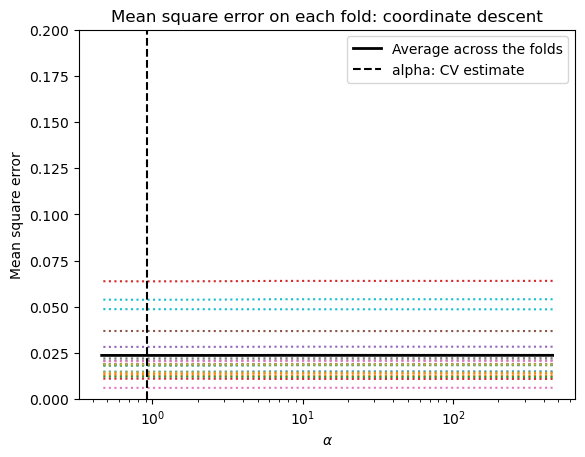

In [76]:
ymin, ymax = 0, 0.2

plt.semilogx(lasso.alphas_, lasso.mse_path_, linestyle=":")
plt.plot(
    lasso.alphas_,
    lasso.mse_path_.mean(axis=-1),
    color="black",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(lasso.alpha_, linestyle="--", color="black", label="alpha: CV estimate")

plt.ylim(ymin, ymax)
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean square error")
plt.legend()
_ = plt.title(
    f"Mean square error on each fold: coordinate descent"
)

Finally, I'm going to use my fitted model from my training data on my testing data. I'll print the R2 value as a measure of how well we predict.

In [77]:
# Evaluate the model on the test data
score = modelcv.score(Xz_test, yz_test)
print(f"Test R-squared: {score}")


Test score: 0.0028149345560726236


Still bad! I guess if you squint, it's a little better than what we did in the training data.

### Hyperparameters and model overfit

Again, what's the point of all of this? We're trying to find our model **hyperparameters** that we can then take to data outside of our training set. We are trying to avoid **overfitting**. This is a problem in machine learning and, especially, in financial applications. It is easy to look at past financial data and fit a model that will predict returns **in sample**, in the data we are using. But, will this work on new data? If you overfit your model, you risk making precisely incorrect predictions.

The figure below shows this problem clearly. As model complexity increases, training accuracy skyrockets -- the model is memorizing the data. But test accuracy (on data the model has never seen) flatlines or even drops. The gap between the two curves *is* the overfitting.

```{figure} ../images/12-overfitting-curve.png
---
name: 12-overfitting-curve.png
align: center
class: with-border
---
The overfitting trap: more complexity does not mean better predictions. Training accuracy rises, but test accuracy stays flat. The "sweet spot" (if any) is where test accuracy peaks before declining. Source: Professor Jonathan Hersh, BUS 696: Generative AI in Finance, Chapman University, Spring 2026.
```

```{warning}
**The in-sample vs. out-of-sample trap.** This is the single most important concept when applying machine learning to finance. Getting 70% accuracy in your training data means almost nothing -- the model may have simply memorized noise. The real test is predicting data the model has never seen, and this is where most financial ML models fail. Financial data has a very low signal-to-noise ratio, patterns are non-stationary (what worked last year may not work this year), and if others discover the same pattern, it gets arbitraged away.
```

Here's a [nice explanation](https://scikit-learn.org/stable/modules/cross_validation.html) on what is going on. This is all part of a much larger discussion on [model selection](https://scikit-learn.org/stable/model_selection.html).

### Some worked examples

We are just scratching the surface on machine learning in this course. Here are some complete examples that all use housing price data. Some things to pay attention to:

- How are the data organized? How is it split into training and test data?
- How is the data quality checked? How are missing values handled? How about outliers?
- What feature engineering steps are used? Are logs taken? Are there categorical variables in the regressions? Are the variables scaled?
- What visualizations are used to look at the data before modeling? Why are they used?
- What models are used? How are they compared?

[Example One.](https://www.kaggle.com/code/erick5/predicting-house-prices-with-machine-learning/notebook)

[Example Two.](https://www.dataquest.io/blog/kaggle-getting-started/)
